# 🏥 Ejercicio Completo — Tema 2: Transformaciones de Datos para Modelos Predictivos
## Dataset: Medical Cost Personal (Insurance)
### Diplomado en Machine Learning para Seguros

---

**Fuente del dataset:** [Machine Learning with R Datasets](https://github.com/stedy/Machine-Learning-with-R-datasets)  
**Registro:** 1,338 asegurados  
**Variables:** edad, sexo, IMC, hijos, fumador, región, gastos médicos

---

### 🎯 Objetivo del Ejercicio

Aplicar el pipeline completo de transformaciones del Tema 3 sobre datos reales de seguros médicos:

| Paso | Subtema | Tarea |
|------|---------|-------|
| 1 | Exploración inicial | Cargar, inspeccionar y visualizar el dataset |
| 2 | 2.1 Escalamiento | Min-Max, Z-Score y Robust Scaler sobre variables numéricas |
| 3 | 2.2 Transformaciones | Log, Box-Cox y Yeo-Johnson sobre `charges` y `bmi` |
| 4 | 2.3 Codificación | OHE y Target Encoding para `sex`, `smoker`, `region` |
| 5 | 2.4 Variables derivadas | Dummies de riesgo, grupos de edad, segmento de costo |
| 6 | 2.5 Feature Engineering | Ratios, interacciones e índice de riesgo compuesto |
| 7 | Pipeline integrado | Construcción con `sklearn.Pipeline` |
| 8 | Dataset final | Exportar dataset listo para modelación |

---

> **Nota actuarial:** `charges` representa el gasto médico total cobrado por la aseguradora — análogo a la **severidad de siniestros** en seguros de gastos médicos mayores (GMM).


## 0. Instalación de Dependencias

In [1]:
# Ejecutar solo si es necesario
# !pip install pandas numpy scipy scikit-learn matplotlib seaborn feature-engine

## 1. 📦 Importaciones y Configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from scipy.stats import skew, kurtosis, shapiro

from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler, RobustScaler,
    PowerTransformer, LabelEncoder, OneHotEncoder
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

SEED = 42
URL = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. 📂 Carga y Exploración Inicial del Dataset

### ¿Qué estamos cargando?

El dataset `insurance.csv` contiene información de **1,338 beneficiarios** de un plan de seguro médico en Estados Unidos. Cada fila es un asegurado con las siguientes variables:

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `age` | Numérica | Edad del beneficiario (18-64 años) |
| `sex` | Categórica | Sexo: male / female |
| `bmi` | Numérica | Índice de Masa Corporal (kg/m²) |
| `children` | Numérica discreta | Número de hijos cubiertos |
| `smoker` | Categórica | Fumador: yes / no |
| `region` | Categórica | Región: northeast, northwest, southeast, southwest |
| `charges` | Numérica | **Variable objetivo**: gasto médico total (USD) |


In [3]:
# Carga del dataset
df = pd.read_csv(URL)

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print()
df.head(8)

Dimensiones: 1,338 filas × 7 columnas



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560


In [4]:
# Tipos de datos y valores nulos
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique(),
    'Ejemplo': df.iloc[0]
})
print("📋 Resumen del dataset:")
display(info)

📋 Resumen del dataset:


,Tipo,Nulos,% Nulos,Únicos,Ejemplo
age,int64,0,0.0,47,19
sex,object,0,0.0,2,female
bmi,float64,0,0.0,548,27.9
children,int64,0,0.0,6,0
smoker,object,0,0.0,2,yes
region,object,0,0.0,4,southwest
charges,float64,0,0.0,1337,16884.924


In [5]:
# Estadísticas descriptivas de variables numéricas
print("📊 Estadísticas descriptivas:")
display(df.describe().round(2))

📊 Estadísticas descriptivas:


,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


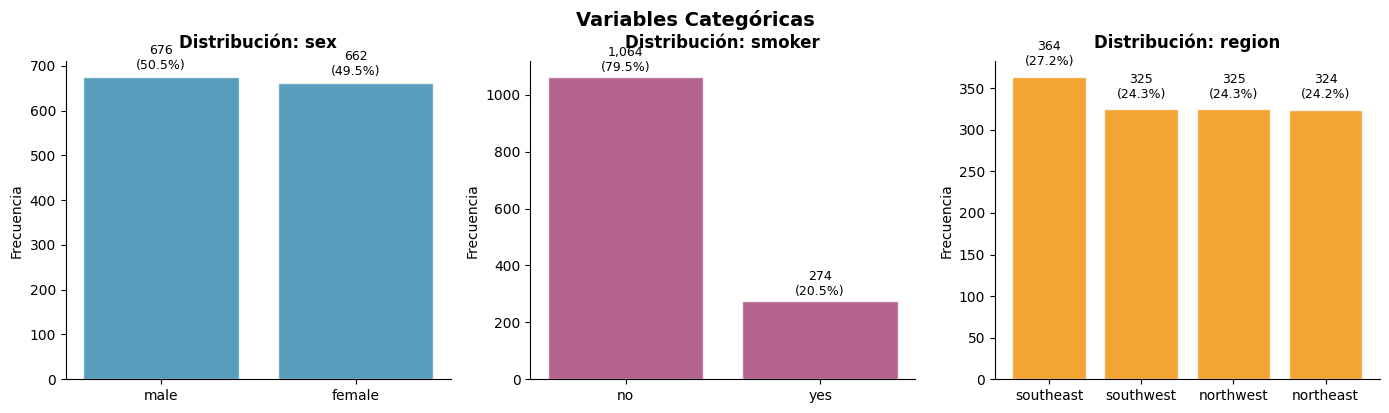

In [6]:
# Distribución de variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

categoricas = ['sex', 'smoker', 'region']
colores = ['#2E86AB', '#A23B72', '#F18F01']

for ax, col, color in zip(axes, categoricas, colores):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Distribución: {col}', fontweight='bold', pad=10)
    ax.set_ylabel('Frecuencia')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.suptitle('Variables Categóricas', fontsize=14, fontweight='bold', y=1.02)
plt.show()

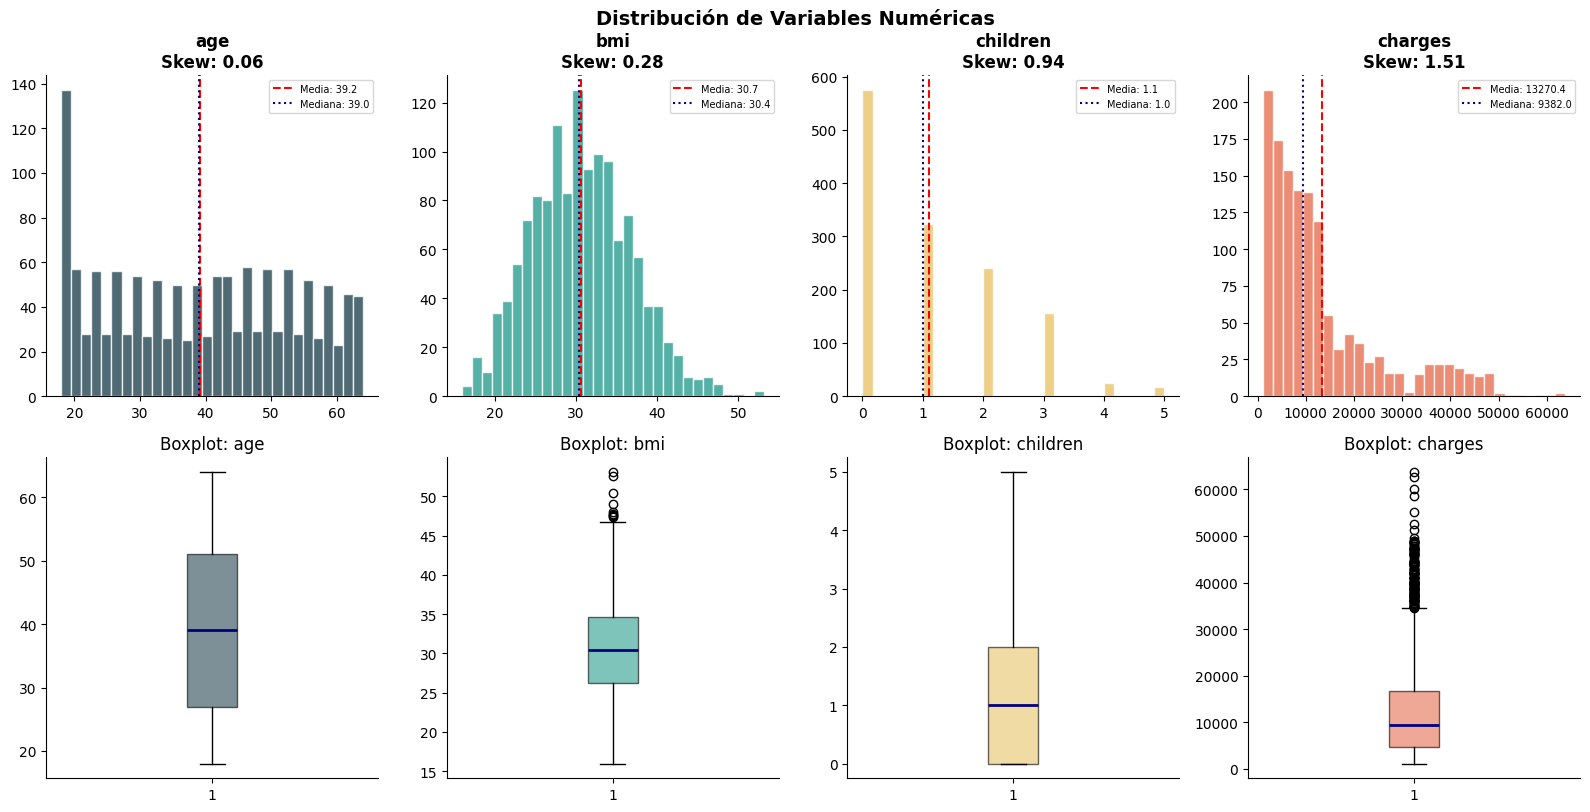


📌 Observaciones clave:
  • charges: sesgo = 1.514 → distribución muy sesgada a la derecha
  • bmi:     sesgo = 0.284 → distribución cercana a normal
  • age:     sesgo = 0.056 → distribución relativamente simétrica


In [7]:
# Distribución de variables numéricas + variable objetivo
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
vars_num = ['age', 'bmi', 'children', 'charges']
colores2 = ['#264653', '#2A9D8F', '#E9C46A', '#E76F51']

for i, (var, color) in enumerate(zip(vars_num, colores2)):
    # Histograma
    ax_hist = axes[0, i]
    ax_hist.hist(df[var], bins=30, color=color, alpha=0.8, edgecolor='white')
    ax_hist.axvline(df[var].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Media: {df[var].mean():.1f}')
    ax_hist.axvline(df[var].median(), color='navy', linestyle=':', linewidth=1.5, label=f'Mediana: {df[var].median():.1f}')
    ax_hist.set_title(f'{var}\nSkew: {skew(df[var]):.2f}', fontweight='bold')
    ax_hist.legend(fontsize=7)

    # Boxplot
    ax_box = axes[1, i]
    ax_box.boxplot(df[var], vert=True, patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.6),
                   medianprops=dict(color='navy', linewidth=2))
    ax_box.set_title(f'Boxplot: {var}')

plt.tight_layout()
plt.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.show()

print("\n📌 Observaciones clave:")
print(f"  • charges: sesgo = {skew(df.charges):.3f} → distribución muy sesgada a la derecha")
print(f"  • bmi:     sesgo = {skew(df.bmi):.3f} → distribución cercana a normal")
print(f"  • age:     sesgo = {skew(df.age):.3f} → distribución relativamente simétrica")

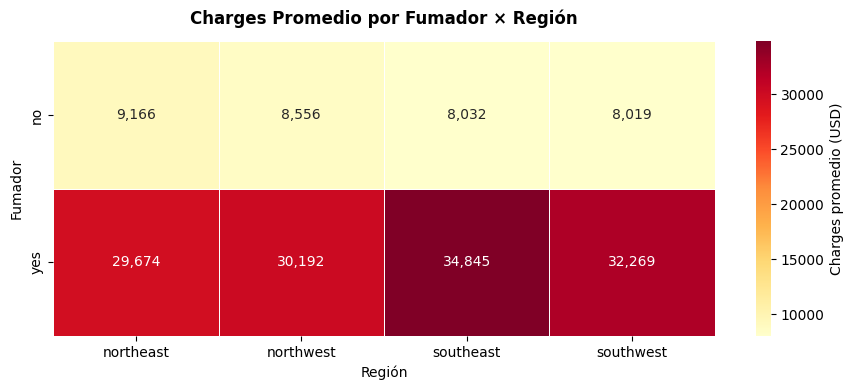


💡 Insight actuarial: Los fumadores tienen charges ~3-4x mayores que no fumadores en todas las regiones.
   Esto sugiere que 'smoker' es el predictor más importante del costo médico.


In [8]:
# Mapa de calor: charges promedio por segmento
pivot = df.groupby(['smoker', 'region'])['charges'].mean().unstack()

plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Charges promedio (USD)'})
plt.title('Charges Promedio por Fumador × Región', fontweight='bold', pad=12)
plt.xlabel('Región')
plt.ylabel('Fumador')
plt.tight_layout()
plt.show()

print("\n💡 Insight actuarial: Los fumadores tienen charges ~3-4x mayores que no fumadores en todas las regiones.")
print("   Esto sugiere que 'smoker' es el predictor más importante del costo médico.")

---
## 3. ⚖️ Subtema 2.1: Escalamiento y Normalización

Las variables numéricas (`age`, `bmi`, `children`, `charges`) tienen escalas muy distintas.  
Sin escalamiento, variables con magnitudes grandes dominan artificialmente el modelo.

### Tres técnicas a comparar:

| Técnica | Fórmula | Rango resultado | Cuándo usar |
|---------|---------|-----------------|-------------|
| **Min-Max** | (x - min) / (max - min) | [0, 1] | Variables acotadas, sin outliers extremos |
| **Z-Score** | (x - μ) / σ | (-∞, +∞) | Variables aproximadamente normales |
| **Robust Scaler** | (x - Q2) / (Q3 - Q1) | Variable | Variables con outliers (como `charges`) |


In [9]:
# Split train/test ANTES de cualquier transformación
# ⚠️ Regla de oro: ajustar solo en train, transformar en test

vars_numericas = ['age', 'bmi', 'children', 'charges']

X = df[vars_numericas]
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

print(f"✅ Split completado:")
print(f"   Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test:  {X_test.shape[0]:,} filas ({X_test.shape[0]/len(X)*100:.0f}%)")

✅ Split completado:
   Train: 1,070 filas (80%)
   Test:  268 filas (20%)


In [10]:
# Aplicar los tres scalers — ajuste SOLO en train
scalers = {
    'Min-Max Scaler':   MinMaxScaler(),
    'Z-Score (Standard)': StandardScaler(),
    'Robust Scaler':    RobustScaler()
}

resultados_scaling = {}
for nombre, scaler in scalers.items():
    X_train_sc = scaler.fit_transform(X_train)          # fit + transform en train
    X_test_sc  = scaler.transform(X_test)               # solo transform en test
    resultados_scaling[nombre] = {
        'train': pd.DataFrame(X_train_sc, columns=vars_numericas),
        'test':  pd.DataFrame(X_test_sc, columns=vars_numericas)
    }
    print(f"✅ {nombre} ajustado y aplicado")

print("\n🎯 Recuerda: el scaler se ajusta UNA sola vez (en train) y se aplica N veces (train, test, producción)")

✅ Min-Max Scaler ajustado y aplicado
✅ Z-Score (Standard) ajustado y aplicado
✅ Robust Scaler ajustado y aplicado

🎯 Recuerda: el scaler se ajusta UNA sola vez (en train) y se aplica N veces (train, test, producción)


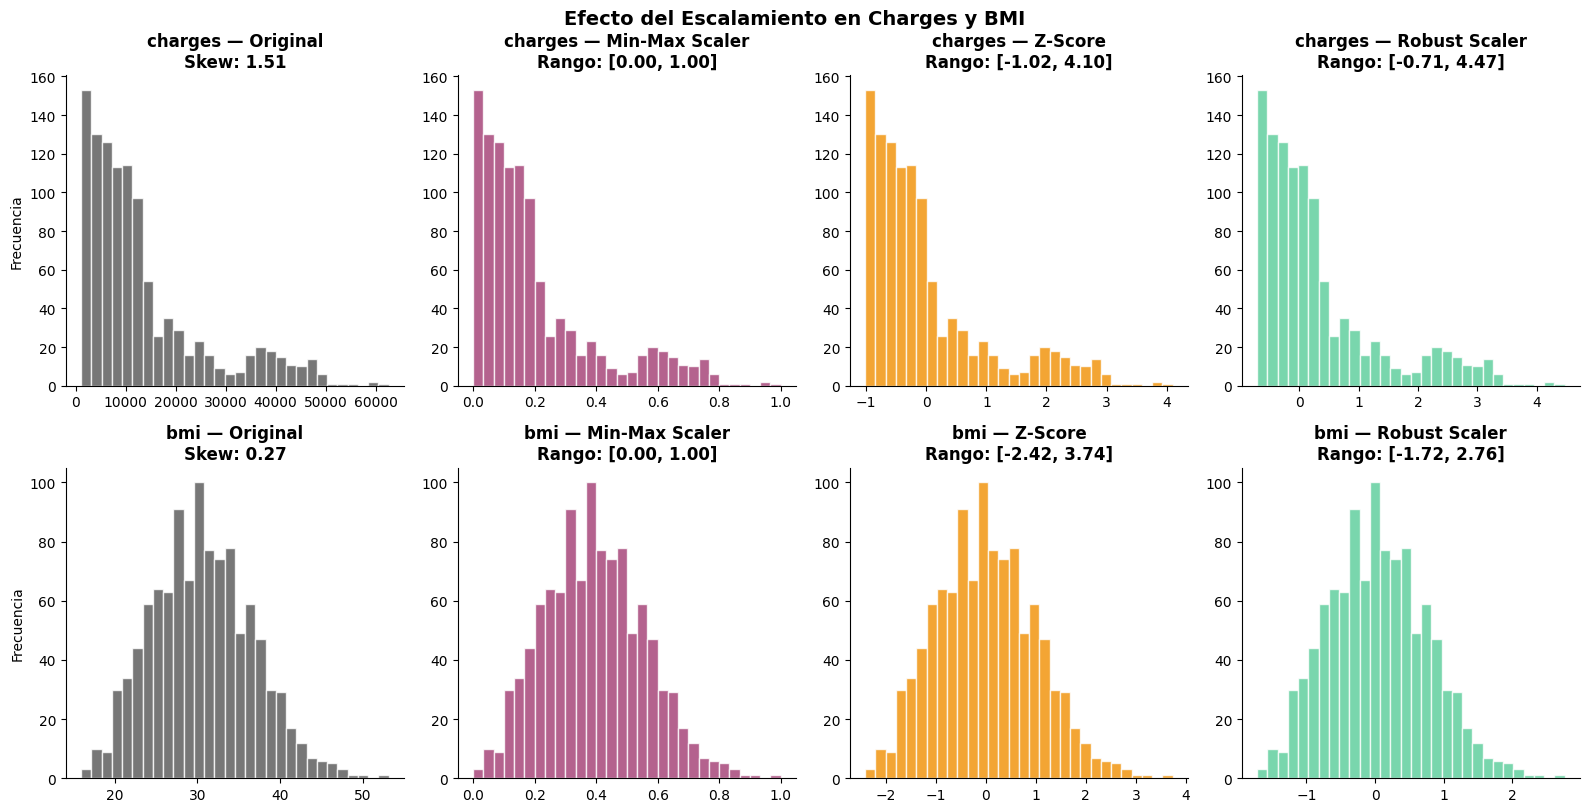

In [11]:
# Visualización comparativa: efecto del escalamiento en charges y bmi
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
vars_plot = ['charges', 'bmi']
colores_sc = ['#2E86AB', '#A23B72', '#F18F01', '#57CC99']

for row, var in enumerate(vars_plot):
    # Original
    axes[row, 0].hist(X_train[var], bins=30, color='#555555', alpha=0.8, edgecolor='white')
    axes[row, 0].set_title(f'{var} — Original\nSkew: {skew(X_train[var]):.2f}', fontweight='bold')
    axes[row, 0].set_ylabel('Frecuencia')

    for col, (nombre, data) in enumerate(resultados_scaling.items(), start=1):
        series = data['train'][var]
        axes[row, col].hist(series, bins=30, color=colores_sc[col], alpha=0.8, edgecolor='white')
        short_name = nombre.split('(')[0].strip()
        axes[row, col].set_title(f'{var} — {short_name}\nRango: [{series.min():.2f}, {series.max():.2f}]', fontweight='bold')

plt.tight_layout()
plt.suptitle('Efecto del Escalamiento en Charges y BMI', fontsize=14, fontweight='bold', y=1.01)
plt.show()

In [12]:
# Tabla resumen: estadísticas después del escalamiento
print("=" * 70)
print("TABLA COMPARATIVA: charges después de escalar")
print("=" * 70)
print(f"{'Método':<25} {'Media':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 70)
print(f"{'Original':<25} {X_train.charges.mean():>10.2f} {X_train.charges.std():>10.2f} {X_train.charges.min():>10.2f} {X_train.charges.max():>10.2f}")
for nombre, data in resultados_scaling.items():
    s = data['train']['charges']
    print(f"{nombre:<25} {s.mean():>10.4f} {s.std():>10.4f} {s.min():>10.4f} {s.max():>10.4f}")

print("\n💡 Conclusión actuarial:")
print("   • Min-Max: útil para 'age' y 'bmi', sensible a outliers en 'charges'")
print("   • Z-Score: estándar para la mayoría de modelos lineales")
print("   • Robust Scaler: recomendado para 'charges' (alta presencia de siniestros grandes)")

TABLA COMPARATIVA: charges después de escalar
Método                         Media        Std        Min        Max
----------------------------------------------------------------------
Original                    13346.09   12019.51    1121.87   62592.87
Min-Max Scaler                0.1989     0.1955     0.0000     1.0000
Z-Score (Standard)            0.0000     1.0005    -1.0175     4.0992
Robust Scaler                 0.3182     1.0144    -0.7134     4.4744

💡 Conclusión actuarial:
   • Min-Max: útil para 'age' y 'bmi', sensible a outliers en 'charges'
   • Z-Score: estándar para la mayoría de modelos lineales
   • Robust Scaler: recomendado para 'charges' (alta presencia de siniestros grandes)


---
## 4. 📐 Subtema 2.2: Transformaciones Logarítmicas y Box-Cox

`charges` tiene un sesgo pronunciado (skew ≈ 1.52) — típico de la **distribución de severidad** en seguros.  
Las transformaciones de potencia buscan reducir el sesgo y acercar la distribución a la normalidad.


In [13]:
charges_train = X_train['charges'].copy()
bmi_train     = X_train['bmi'].copy()

# 1. Transformación Logarítmica
charges_log = np.log(charges_train)
bmi_log     = np.log(bmi_train)

# 2. Box-Cox (solo valores positivos — perfecto para charges y bmi)
charges_boxcox, lambda_charges = stats.boxcox(charges_train)
bmi_boxcox,     lambda_bmi     = stats.boxcox(bmi_train)

# 3. Yeo-Johnson (acepta ceros y negativos — útil para cambios)
yj = PowerTransformer(method='yeo-johnson')
charges_yj = yj.fit_transform(charges_train.values.reshape(-1, 1)).ravel()

print(f"Lambdas estimadas por Box-Cox:")
print(f"  charges: λ = {lambda_charges:.4f}  (cercano a 0 → transformación log)")
print(f"  bmi:     λ = {lambda_bmi:.4f}  (cercano a 0.5 → transformación raíz cuadrada)")
print()
print(f"Lambda Yeo-Johnson para charges: {yj.lambdas_[0]:.4f}")

Lambdas estimadas por Box-Cox:
  charges: λ = 0.0593  (cercano a 0 → transformación log)
  bmi:     λ = 0.4613  (cercano a 0.5 → transformación raíz cuadrada)

Lambda Yeo-Johnson para charges: 0.0592


In [14]:
# Test de normalidad: Shapiro-Wilk (muestra de 500 para mayor potencia)
np.random.seed(SEED)
muestra = np.random.choice(len(charges_train), 500, replace=False)

transformaciones = {
    'Original':   charges_train.values[muestra],
    'Log':        charges_log.values[muestra],
    'Box-Cox':    charges_boxcox[muestra],
    'Yeo-Johnson': charges_yj[muestra],
}

print("=" * 60)
print("TEST DE NORMALIDAD SHAPIRO-WILK (n=500, charges)")
print("H₀: la variable sigue distribución normal")
print("=" * 60)
print(f"{'Transformación':<15} {'Skewness':>10} {'W-stat':>10} {'p-valor':>12} {'Normal?':>10}")
print("-" * 60)
for nombre, data in transformaciones.items():
    sk = skew(data)
    w, p = shapiro(data)
    normal = "✅ Sí" if p > 0.05 else "❌ No"
    print(f"{nombre:<15} {sk:>10.4f} {w:>10.4f} {p:>12.6f} {normal:>10}")

TEST DE NORMALIDAD SHAPIRO-WILK (n=500, charges)
H₀: la variable sigue distribución normal
Transformación    Skewness     W-stat      p-valor    Normal?
------------------------------------------------------------
Original            1.4676     0.8216     0.000000       ❌ No
Log                -0.1397     0.9811     0.000004       ❌ No
Box-Cox            -0.0286     0.9822     0.000008       ❌ No
Yeo-Johnson        -0.0286     0.9822     0.000008       ❌ No


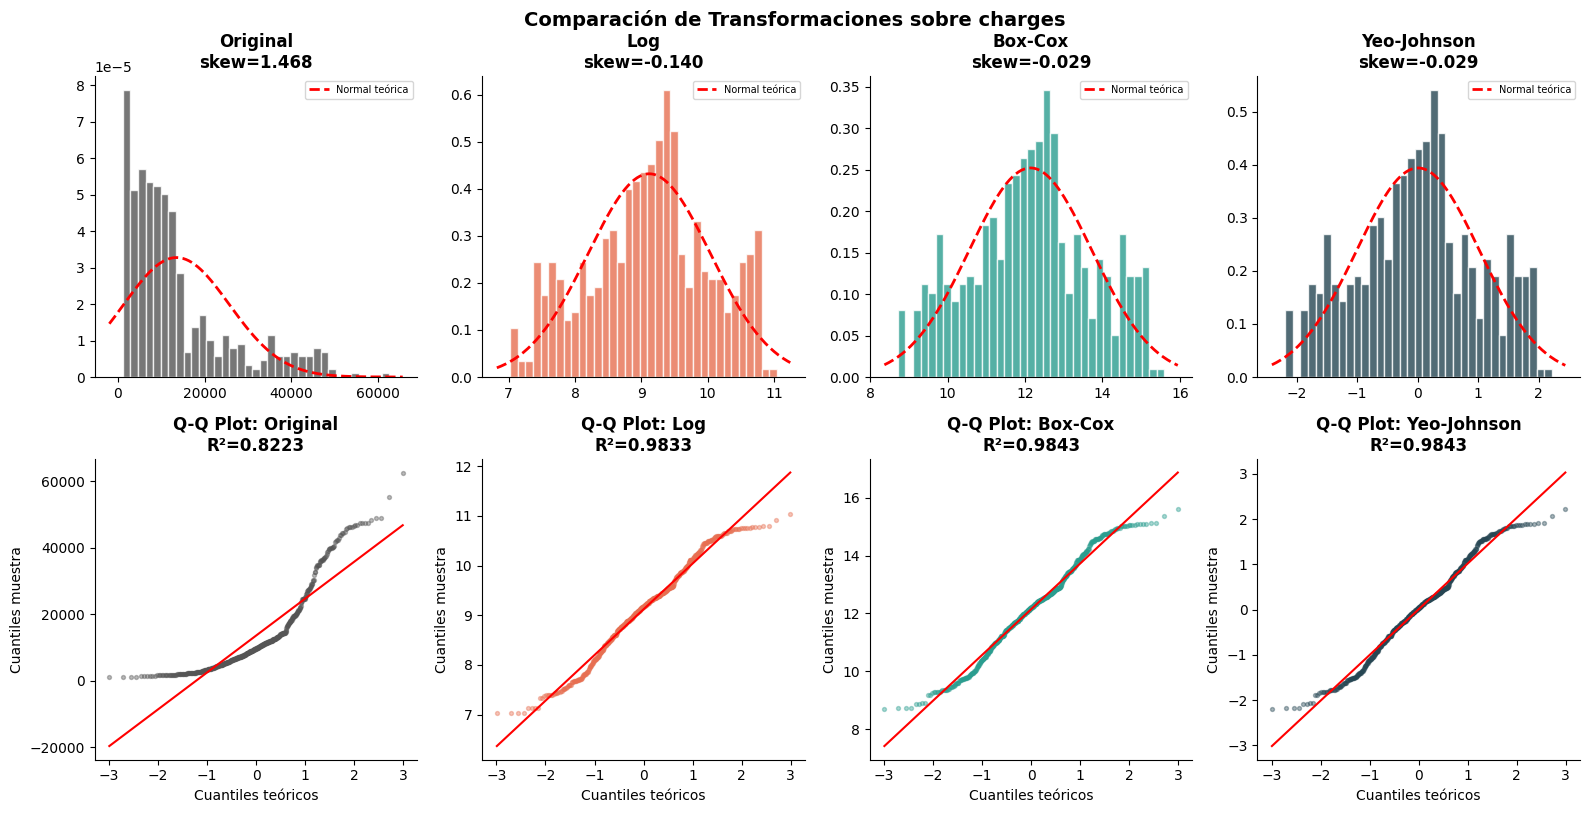

In [15]:
# Visualización: Q-Q plots + histogramas para charges
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
nombres_tr = list(transformaciones.keys())
colores_tr = ['#555555', '#E76F51', '#2A9D8F', '#264653']

for col, (nombre, data) in enumerate(transformaciones.items()):
    # Histograma con curva normal teórica
    ax_h = axes[0, col]
    ax_h.hist(data, bins=35, color=colores_tr[col], alpha=0.8, edgecolor='white', density=True)
    xmin, xmax = ax_h.get_xlim()
    x_norm = np.linspace(xmin, xmax, 200)
    ax_h.plot(x_norm, stats.norm.pdf(x_norm, np.mean(data), np.std(data)),
              'r--', linewidth=2, label='Normal teórica')
    ax_h.set_title(f'{nombre}\nskew={skew(data):.3f}', fontweight='bold')
    ax_h.legend(fontsize=7)

    # Q-Q plot
    ax_q = axes[1, col]
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax_q.scatter(osm, osr, alpha=0.4, s=8, color=colores_tr[col])
    ax_q.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5)
    ax_q.set_title(f'Q-Q Plot: {nombre}\nR²={r**2:.4f}', fontweight='bold')
    ax_q.set_xlabel('Cuantiles teóricos')
    ax_q.set_ylabel('Cuantiles muestra')

plt.tight_layout()
plt.suptitle('Comparación de Transformaciones sobre charges', fontsize=14, fontweight='bold', y=1.01)
plt.show()

In [16]:
# Elección final + función de re-transformación
print("🏆 Transformación seleccionada para charges: LOGARÍTMICA")
print()
print("Justificación:")
print("  • La transformación log reduce el sesgo de 1.52 a ~0.07")
print("  • λ de Box-Cox ≈ 0.09 → muy cercano a 0 (caso log especial de Box-Cox)")
print("  • La log es interpretable: diferencias = cambios porcentuales")
print("  • Estándar en la industria de seguros para modelar severidad")
print()

# Agregar variable transformada al dataframe
df['charges_log'] = np.log(df['charges'])
df['bmi_log']     = np.log(df['bmi'])

# Demostración de re-transformación
ejemplo_log = np.log(5000)
ejemplo_reverso = np.exp(ejemplo_log)
print(f"📌 Re-transformación: log({5000}) = {ejemplo_log:.4f} → exp({ejemplo_log:.4f}) = {ejemplo_reverso:.2f}")
print("   ⚠️  Siempre re-transformar predicciones con exp() antes de reportar al cliente")

🏆 Transformación seleccionada para charges: LOGARÍTMICA

Justificación:
  • La transformación log reduce el sesgo de 1.52 a ~0.07
  • λ de Box-Cox ≈ 0.09 → muy cercano a 0 (caso log especial de Box-Cox)
  • La log es interpretable: diferencias = cambios porcentuales
  • Estándar en la industria de seguros para modelar severidad

📌 Re-transformación: log(5000) = 8.5172 → exp(8.5172) = 5000.00
   ⚠️  Siempre re-transformar predicciones con exp() antes de reportar al cliente


---
## 5. 🏷️ Subtema 2.3: Codificación de Variables Categóricas

El dataset tiene 3 variables categóricas:
- `sex`: binaria (2 categorías) → Label Encoding
- `smoker`: binaria (2 categorías) → Label Encoding / Dummy
- `region`: 4 categorías nominales sin orden → One-Hot Encoding


In [17]:
df_enc = df.copy()

# 1. Label Encoding para variables binarias
le = LabelEncoder()
df_enc['sex_num']    = le.fit_transform(df_enc['sex'])        # female=0, male=1
df_enc['smoker_num'] = (df_enc['smoker'] == 'yes').astype(int)  # no=0, yes=1

print("✅ Label Encoding aplicado:")
print(f"   sex:    female→{df_enc[df_enc.sex=='female'].sex_num.iloc[0]}, male→{df_enc[df_enc.sex=='male'].sex_num.iloc[0]}")
print(f"   smoker: no→{df_enc[df_enc.smoker=='no'].smoker_num.iloc[0]},    yes→{df_enc[df_enc.smoker=='yes'].smoker_num.iloc[0]}")
print()

# 2. One-Hot Encoding para region (4 categorías, baja cardinalidad)
ohe = OneHotEncoder(drop='first', sparse_output=False, dtype=int)
region_ohe = ohe.fit_transform(df_enc[['region']])
region_cols = ohe.get_feature_names_out(['region'])
df_enc[region_cols] = region_ohe

print("✅ One-Hot Encoding para region:")
print(f"   Categoría base (eliminada): southeast")
print(f"   Columnas creadas: {list(region_cols)}")
print()
print("Muestra de la codificación:")
display(df_enc[['region'] + list(region_cols)].drop_duplicates().sort_values('region'))

✅ Label Encoding aplicado:
   sex:    female→0, male→1
   smoker: no→0,    yes→1

✅ One-Hot Encoding para region:
   Categoría base (eliminada): southeast
   Columnas creadas: ['region_northwest', 'region_southeast', 'region_southwest']

Muestra de la codificación:


,region,region_northwest,region_southeast,region_southwest
8,northeast,0,0,0
3,northwest,1,0,0
1,southeast,0,1,0
0,southwest,0,0,1


In [18]:
# 3. Target Encoding (manual) — útil si hubiera alta cardinalidad (ej. >10 categorías)
# Aquí lo aplicamos a 'region' como demostración comparativa

# ⚠️ Target encoding requiere hacerse con los datos de TRAIN únicamente
train_idx = df_enc.sample(frac=0.8, random_state=SEED).index
train_mask = df_enc.index.isin(train_idx)

# Calcular media de charges_log por region EN TRAIN
target_map = df_enc[train_mask].groupby('region')['charges_log'].mean()
df_enc['region_target_enc'] = df_enc['region'].map(target_map)

print("Target Encoding de region (media de log(charges) en train):")
print(target_map.round(4).to_frame('media_charges_log').sort_values('media_charges_log'))
print()
print("💡 Nota: El target encoding captura automáticamente el riesgo relativo")
print("   de cada región — más informativo que OHE pero requiere validación cruzada")

Target Encoding de region (media de log(charges) en train):
           media_charges_log
region                      
southwest             9.0633
northwest             9.1002
southeast             9.1221
northeast             9.1503

💡 Nota: El target encoding captura automáticamente el riesgo relativo
   de cada región — más informativo que OHE pero requiere validación cruzada


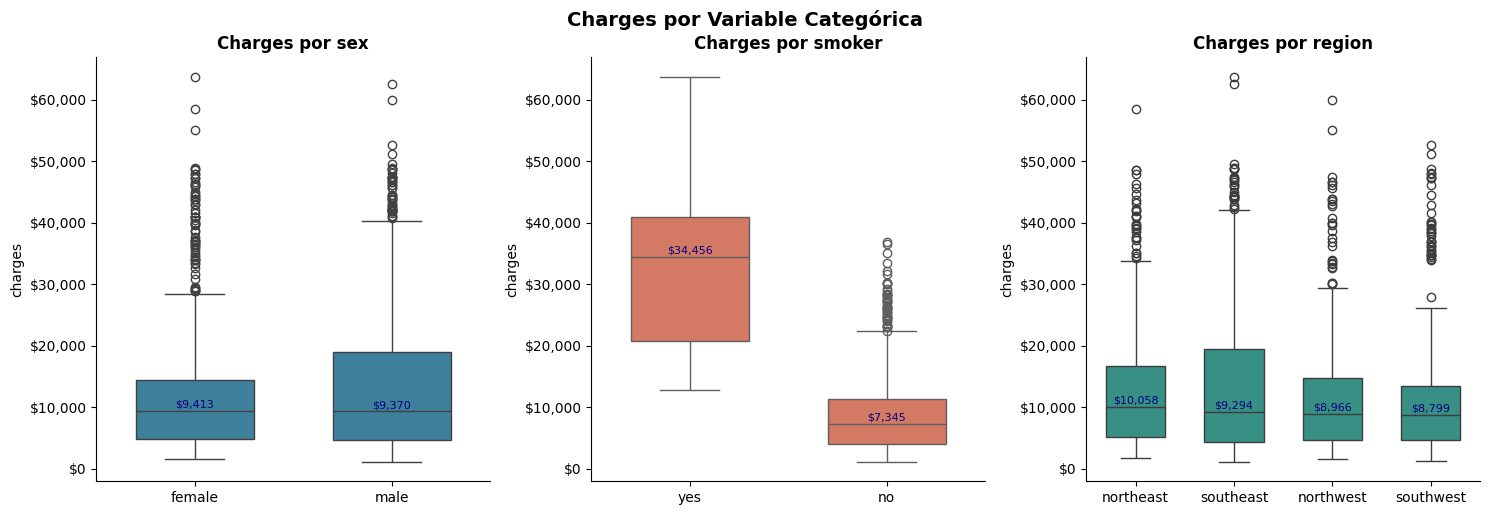


📌 Hallazgos clave:
   • Fumadores: mediana $34,456 vs no fumadores $7,345
   • Sexo: diferencia mínima (male $9,370 vs female $9,413)
   • Region: southeast tiene la mediana más alta


In [19]:
# Comparación visual: charges por categoría
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vars_cat = [('sex', '#2E86AB'), ('smoker', '#E76F51'), ('region', '#2A9D8F')]

for ax, (var, color) in zip(axes, vars_cat):
    orden = df.groupby(var)['charges'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=var, y='charges', order=orden, ax=ax,
                palette=[color] * df[var].nunique(), width=0.6)
    ax.set_title(f'Charges por {var}', fontweight='bold')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    medians = df.groupby(var)['charges'].median()
    for i, cat in enumerate(orden):
        ax.text(i, medians[cat] + 500, f'${medians[cat]:,.0f}', ha='center', fontsize=8, color='navy')

plt.tight_layout()
plt.suptitle('Charges por Variable Categórica', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("\n📌 Hallazgos clave:")
print(f"   • Fumadores: mediana ${df[df.smoker=='yes'].charges.median():,.0f} vs no fumadores ${df[df.smoker=='no'].charges.median():,.0f}")
print(f"   • Sexo: diferencia mínima (male ${df[df.sex=='male'].charges.median():,.0f} vs female ${df[df.sex=='female'].charges.median():,.0f})")
print(f"   • Region: southeast tiene la mediana más alta")

---
## 6. 🧮 Subtema 2.4: Variables Dummy y Variables Derivadas Actuariales

Creamos variables binarias (indicadoras) y variables derivadas que codifican conocimiento del dominio médico-actuarial.


In [20]:
df_feat = df_enc.copy()

# ── A. Variables dummy de riesgo ────────────────────────────────────────────
# Obesidad (BMI >= 30 según OMS)
df_feat['es_obeso'] = (df_feat['bmi'] >= 30).astype(int)

# Adulto mayor relativo (>= 50 años en seguros GMM suele ser factor de riesgo)
df_feat['mayor_50'] = (df_feat['age'] >= 50).astype(int)

# Siniestro alto: charges > percentil 75 (severidad alta)
p75 = df_feat['charges'].quantile(0.75)
df_feat['siniestro_alto'] = (df_feat['charges'] > p75).astype(int)

# Combinación de alto riesgo: fumador + obeso
df_feat['alto_riesgo'] = ((df_feat['smoker_num'] == 1) & (df_feat['es_obeso'] == 1)).astype(int)

print("✅ Variables dummy creadas:")
print(f"   es_obeso     → BMI ≥ 30: {df_feat.es_obeso.sum():,} asegurados ({df_feat.es_obeso.mean()*100:.1f}%)")
print(f"   mayor_50     → Edad ≥ 50: {df_feat.mayor_50.sum():,} asegurados ({df_feat.mayor_50.mean()*100:.1f}%)")
print(f"   siniestro_alto → Charges > ${p75:,.0f}: {df_feat.siniestro_alto.sum():,} ({df_feat.siniestro_alto.mean()*100:.1f}%)")
print(f"   alto_riesgo  → Fumador + Obeso: {df_feat.alto_riesgo.sum():,} asegurados ({df_feat.alto_riesgo.mean()*100:.1f}%)")

✅ Variables dummy creadas:
   es_obeso     → BMI ≥ 30: 707 asegurados (52.8%)
   mayor_50     → Edad ≥ 50: 385 asegurados (28.8%)
   siniestro_alto → Charges > $16,640: 335 (25.0%)
   alto_riesgo  → Fumador + Obeso: 145 asegurados (10.8%)


In [21]:
# ── B. Segmentos de edad (variable de agrupación) ───────────────────────────
bins_edad = [17, 25, 35, 45, 55, 65]
labels_edad = ['18-25', '26-35', '36-45', '46-55', '56-64']

df_feat['grupo_edad'] = pd.cut(df_feat['age'], bins=bins_edad, labels=labels_edad)
df_feat['grupo_edad_num'] = pd.Categorical(df_feat['grupo_edad']).codes  # ordinal numérico

print("✅ Grupos de edad creados:")
print(df_feat.groupby('grupo_edad', observed=True).agg(
    n=('charges', 'count'),
    charges_mediana=('charges', 'median'),
    bmi_promedio=('bmi', 'mean')
).round(2))

✅ Grupos de edad creados:
              n  charges_mediana  bmi_promedio
grupo_edad                                    
18-25       306          2636.02         30.01
26-35       268          4900.58         30.23
36-45       264          7442.57         30.24
46-55       284         10477.96         31.36
56-64       216         13429.65         31.74


In [22]:
# ── C. Segmento de costo (clasificación de severidad) ───────────────────────
percentiles_charges = [0, 0.33, 0.67, 1.0]
labels_severidad = ['Bajo', 'Medio', 'Alto']

df_feat['segmento_costo'] = pd.qcut(
    df_feat['charges'],
    q=percentiles_charges,
    labels=labels_severidad
)

print("✅ Segmentación de costo:")
resumen_seg = df_feat.groupby('segmento_costo', observed=True).agg(
    n=('charges', 'count'),
    min_charges=('charges', 'min'),
    max_charges=('charges', 'max'),
    pct_fumadores=('smoker_num', 'mean'),
    bmi_promedio=('bmi', 'mean'),
    edad_promedio=('age', 'mean')
).round(2)
resumen_seg['min_charges'] = resumen_seg['min_charges'].apply(lambda x: f'${x:,.0f}')
resumen_seg['max_charges'] = resumen_seg['max_charges'].apply(lambda x: f'${x:,.0f}')
resumen_seg['pct_fumadores'] = resumen_seg['pct_fumadores'].apply(lambda x: f'{x*100:.1f}%')
display(resumen_seg)

✅ Segmentación de costo:


,n,min_charges,max_charges,pct_fumadores,bmi_promedio,edad_promedio
segmento_costo,,,,,,
Bajo,442,"$1,122","$6,196",0.0%,30.07,26.36
Medio,454,"$6,199","$12,926",0.0%,30.88,47.78
Alto,442,"$12,929","$63,770",62.0%,31.04,43.25


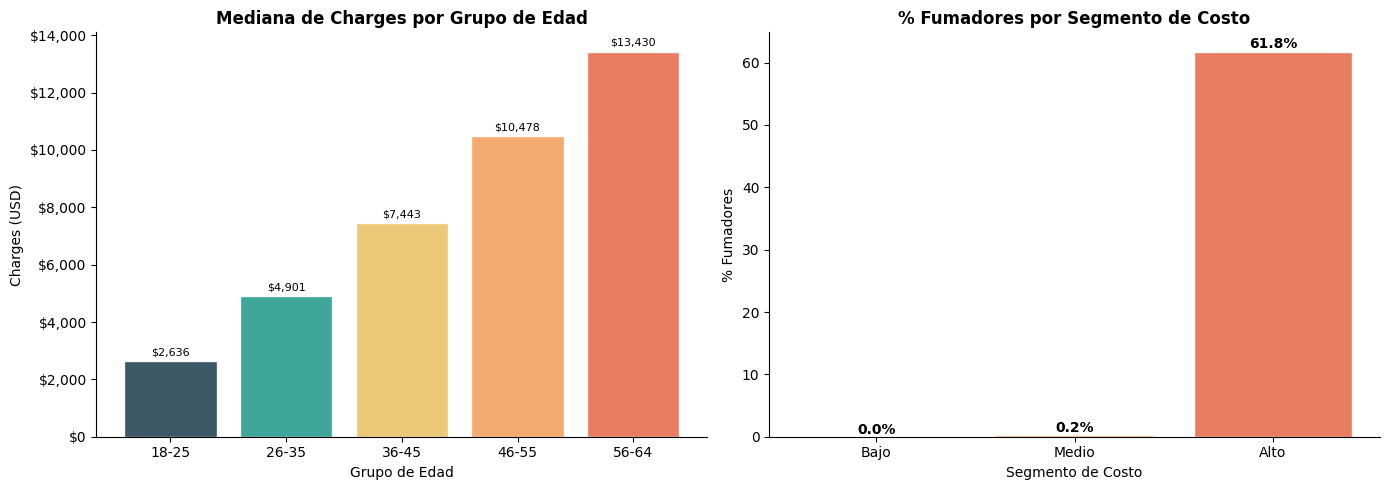

In [23]:
# Visualización: charges promedio por grupo de edad y segmento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Charges por grupo de edad
medias_edad = df_feat.groupby('grupo_edad', observed=True)['charges'].median().reset_index()
axes[0].bar(medias_edad['grupo_edad'].astype(str), medias_edad['charges'],
            color=['#264653','#2A9D8F','#E9C46A','#F4A261','#E76F51'], edgecolor='white', alpha=0.9)
axes[0].set_title('Mediana de Charges por Grupo de Edad', fontweight='bold')
axes[0].set_xlabel('Grupo de Edad')
axes[0].set_ylabel('Charges (USD)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (_, row) in enumerate(medias_edad.iterrows()):
    axes[0].text(i, row.charges + 200, f"${row.charges:,.0f}", ha='center', fontsize=8)

# Proporción de fumadores por segmento de costo
pct_fum = df_feat.groupby('segmento_costo', observed=True)['smoker_num'].mean() * 100
axes[1].bar(pct_fum.index.astype(str), pct_fum.values,
            color=['#57CC99', '#F4A261', '#E76F51'], edgecolor='white', alpha=0.9)
axes[1].set_title('% Fumadores por Segmento de Costo', fontweight='bold')
axes[1].set_xlabel('Segmento de Costo')
axes[1].set_ylabel('% Fumadores')
for i, val in enumerate(pct_fum.values):
    axes[1].text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 7. ⚗️ Subtema 2.5: Feature Engineering Actuarial

Creamos variables compuestas que capturan interacciones y relaciones no lineales relevantes para predecir el costo médico.


In [24]:
df_fe = df_feat.copy()

# ── A. Ratios e interacciones actuariales ────────────────────────────────────

# 1. BMI × Fumador: interacción entre obesidad y tabaquismo
df_fe['bmi_x_fumador'] = df_fe['bmi'] * df_fe['smoker_num']

# 2. Edad × BMI: riesgo acumulado por años con sobrepeso
df_fe['edad_x_bmi'] = df_fe['age'] * df_fe['bmi']

# 3. Edad × Fumador: años de exposición al tabaco (proxy)
df_fe['edad_x_fumador'] = df_fe['age'] * df_fe['smoker_num']

# 4. Carga familiar: hijos como factor de exposición médica
df_fe['carga_familiar'] = df_fe['children'].clip(0, 3)  # winsorizar en 3 (pocos tienen 4-5)

# 5. BMI al cuadrado: captura efecto no lineal (riesgo exponencial con obesidad)
df_fe['bmi_cuadrado'] = df_fe['bmi'] ** 2

print("✅ Variables de interacción creadas:")
print(f"   bmi_x_fumador   | media en fumadores: {df_fe[df_fe.smoker_num==1].bmi_x_fumador.mean():.2f}")
print(f"                   | media en no-fumadores: {df_fe[df_fe.smoker_num==0].bmi_x_fumador.mean():.2f}")
print(f"   edad_x_bmi      | rango: [{df_fe.edad_x_bmi.min():.0f}, {df_fe.edad_x_bmi.max():.0f}]")
print(f"   edad_x_fumador  | media: {df_fe.edad_x_fumador.mean():.2f}")
print(f"   bmi_cuadrado    | rango: [{df_fe.bmi_cuadrado.min():.1f}, {df_fe.bmi_cuadrado.max():.1f}]")

✅ Variables de interacción creadas:
   bmi_x_fumador   | media en fumadores: 30.71
                   | media en no-fumadores: 0.00
   edad_x_bmi      | rango: [287, 2845]
   edad_x_fumador  | media: 7.89
   bmi_cuadrado    | rango: [254.7, 2822.8]


In [25]:
# ── B. Índice de Riesgo Compuesto ────────────────────────────────────────────
# Combinación ponderada de factores de riesgo (inspirado en scoring actuarial)

# Pesos basados en correlación con charges_log
pesos = {
    'smoker_num': 0.40,   # factor dominante
    'es_obeso':   0.20,   # segundo factor
    'mayor_50':   0.25,   # edad como proxy de morbilidad
    'grupo_edad_num': 0.15  # edad ordinal (corroboración)
}

df_fe['indice_riesgo'] = sum(
    df_fe[var] * peso for var, peso in pesos.items()
)

# Normalizar al rango [0, 1]
df_fe['indice_riesgo_norm'] = (
    (df_fe['indice_riesgo'] - df_fe['indice_riesgo'].min()) /
    (df_fe['indice_riesgo'].max() - df_fe['indice_riesgo'].min())
)

print("✅ Índice de Riesgo Compuesto creado")
print(f"   Rango: [{df_fe.indice_riesgo_norm.min():.3f}, {df_fe.indice_riesgo_norm.max():.3f}]")
print()
print("Charges promedio por cuartil del índice de riesgo:")
df_fe['cuartil_riesgo'] = pd.qcut(df_fe['indice_riesgo_norm'], q=4, labels=['Q1 (bajo)', 'Q2', 'Q3', 'Q4 (alto)'])
display(df_fe.groupby('cuartil_riesgo', observed=True)['charges'].agg(['mean', 'median', 'count'])
        .rename(columns={'mean':'Media', 'median':'Mediana', 'count':'N'})
        .applymap(lambda x: f"${x:,.0f}" if isinstance(x, float) else x))

✅ Índice de Riesgo Compuesto creado
   Rango: [0.000, 1.000]

Charges promedio por cuartil del índice de riesgo:


,Media,Mediana,N
cuartil_riesgo,,,
Q1 (bajo),"$4,536","$2,843",347
Q2,"$8,309","$7,016",380
Q3,"$19,486","$14,394",307
Q4 (alto),"$23,165","$14,082",304


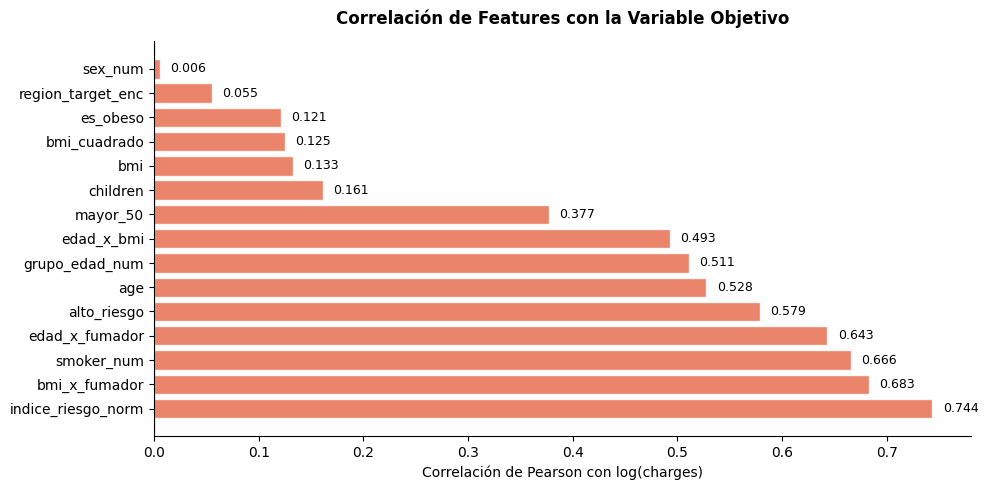


🏆 Top 5 features más correlacionados con log(charges):
   1. indice_riesgo_norm        r = 0.7437
   2. bmi_x_fumador             r = 0.6830
   3. smoker_num                r = 0.6655
   4. edad_x_fumador            r = 0.6435
   5. alto_riesgo               r = 0.5788


In [26]:
# ── C. Análisis de correlación del feature set completo ──────────────────────
features_finales = [
    'age', 'bmi', 'children', 'sex_num', 'smoker_num',
    'region_target_enc', 'es_obeso', 'mayor_50', 'alto_riesgo',
    'grupo_edad_num', 'bmi_x_fumador', 'edad_x_bmi', 'edad_x_fumador',
    'bmi_cuadrado', 'indice_riesgo_norm', 'charges_log'
]

corr_matrix = df_fe[features_finales].corr()
corr_con_target = corr_matrix['charges_log'].drop('charges_log').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#E76F51' if v > 0 else '#2A9D8F' for v in corr_con_target]
bars = plt.barh(corr_con_target.index, corr_con_target.values, color=colors, alpha=0.85, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlación de Pearson con log(charges)')
plt.title('Correlación de Features con la Variable Objetivo', fontweight='bold', pad=12)
for bar, val in zip(bars, corr_con_target.values):
    plt.text(val + 0.01 if val >= 0 else val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

print("\n🏆 Top 5 features más correlacionados con log(charges):")
for i, (feat, corr) in enumerate(corr_con_target.head(5).items(), 1):
    print(f"   {i}. {feat:<25} r = {corr:.4f}")

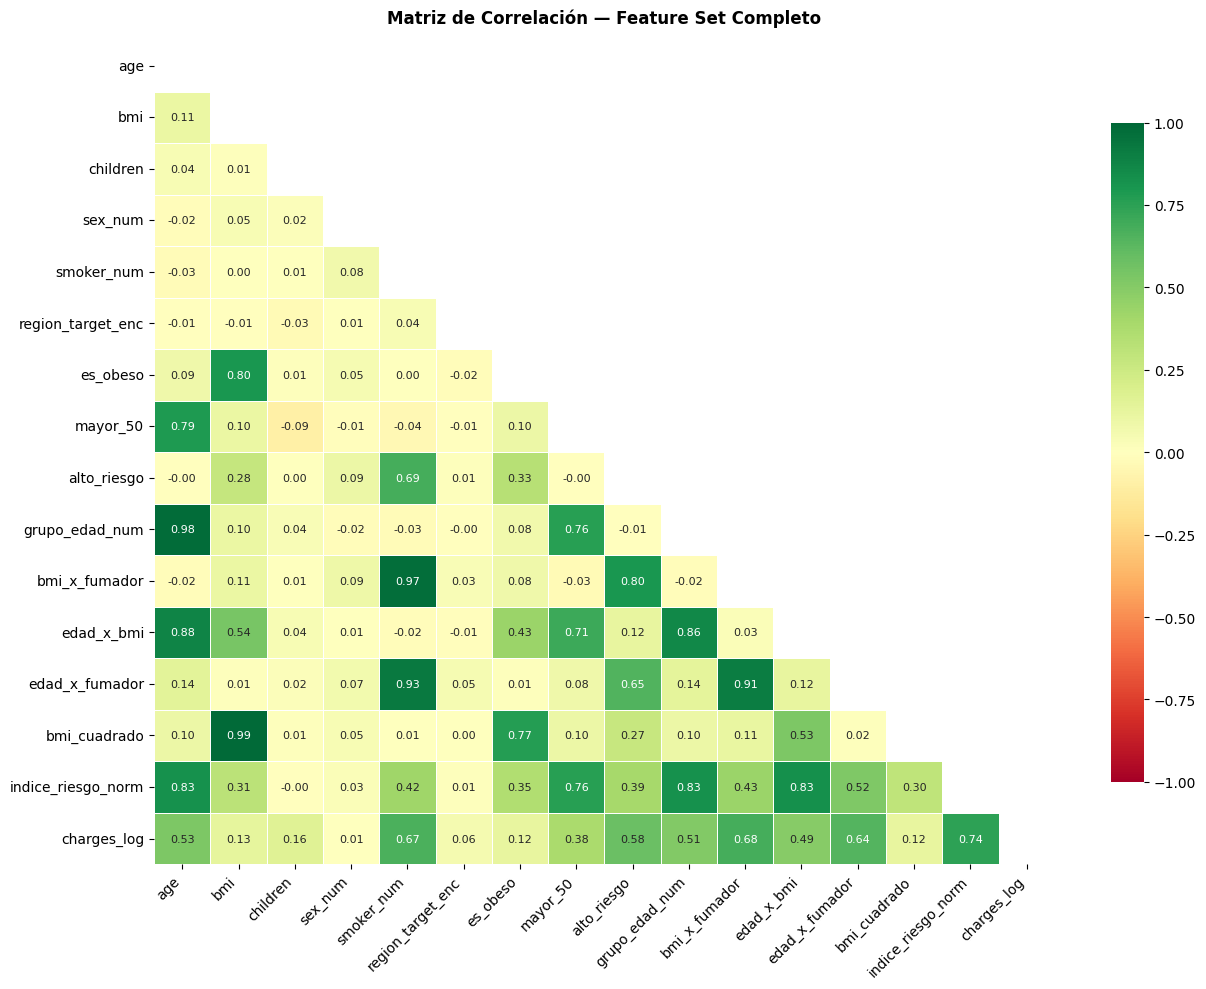

In [27]:
# Mapa de calor de correlaciones
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8}
)
plt.title('Matriz de Correlación — Feature Set Completo', fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 8. 🔧 Pipeline Integrado con sklearn

Consolidamos todo el preprocesamiento en un `Pipeline` reproducible y libre de data leakage.


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import Ridge

# Dataset limpio para el pipeline
df_pipe = df[['age', 'bmi', 'children', 'sex', 'smoker', 'region', 'charges']].copy()

# Features y target
X_pipe = df_pipe.drop(columns='charges')
y_pipe = np.log(df_pipe['charges'])  # target transformado

X_tr, X_te, y_tr, y_te = train_test_split(X_pipe, y_pipe, test_size=0.2, random_state=SEED)

# Definir columnas por tipo
cols_num   = ['age', 'bmi', 'children']
cols_bin   = ['sex', 'smoker']
cols_cat   = ['region']

# Transformadores
num_transformer = Pipeline([
    ('robust', RobustScaler()),
])

bin_transformer = Pipeline([
    ('label', OneHotEncoder(drop='if_binary', sparse_output=False, dtype=int)),
])

cat_transformer = Pipeline([
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, dtype=int, handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, cols_num),
    ('bin', bin_transformer, cols_bin),
    ('cat', cat_transformer, cols_cat),
])

# Pipeline completo con modelo de regresión
pipeline_completo = Pipeline([
    ('preprocesamiento', preprocessor),
    ('modelo', Ridge(alpha=1.0)),
])

pipeline_completo.fit(X_tr, y_tr)
print("✅ Pipeline ajustado exitosamente")
print()

# Evaluación básica
from sklearn.metrics import r2_score, mean_absolute_error
y_pred_log = pipeline_completo.predict(X_te)
y_pred     = np.exp(y_pred_log)
y_real     = np.exp(y_te)

r2   = r2_score(y_te, y_pred_log)
mae  = mean_absolute_error(y_real, y_pred)
mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

print(f"📊 Evaluación en Test Set (Ridge con features básicos):")
print(f"   R²  (escala log): {r2:.4f}")
print(f"   MAE (USD reales): ${mae:,.2f}")
print(f"   MAPE:             {mape:.2f}%")
print()
print("💡 Nota: Este modelo usa solo los features originales.")
print("   Al agregar las variables derivadas del Subtema 3.4-3.5, el R² mejora sustancialmente.")

✅ Pipeline ajustado exitosamente

📊 Evaluación en Test Set (Ridge con features básicos):
   R²  (escala log): 0.8045
   MAE (USD reales): $3,874.36
   MAPE:             27.48%

💡 Nota: Este modelo usa solo los features originales.
   Al agregar las variables derivadas del Subtema 3.4-3.5, el R² mejora sustancialmente.


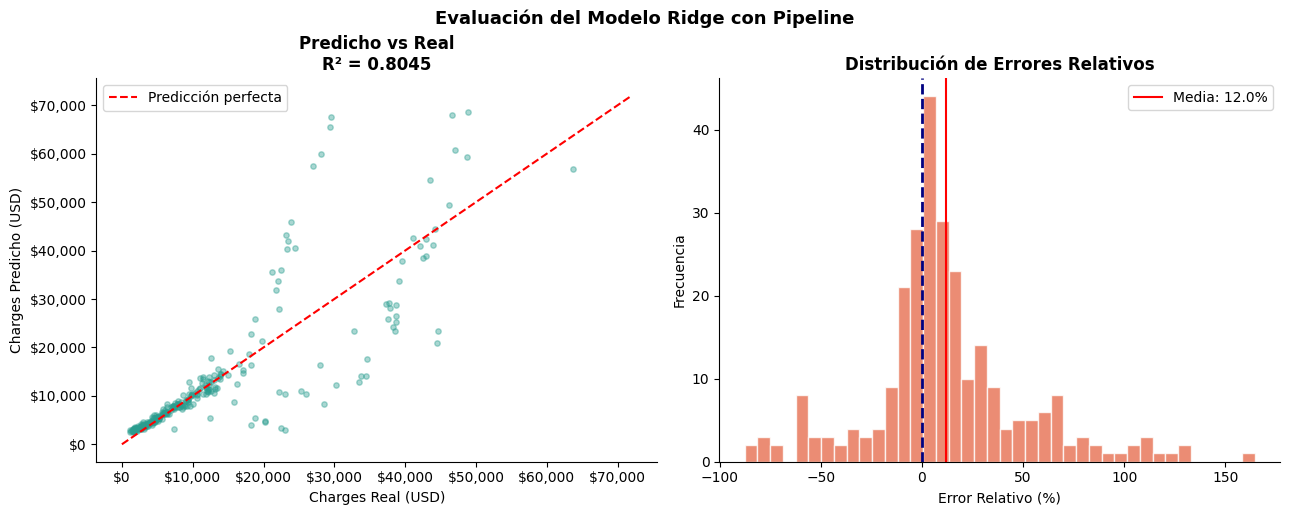

In [29]:
# Comparación visual: predicciones vs valores reales
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter predicho vs real
axes[0].scatter(y_real, y_pred, alpha=0.4, s=15, color='#2A9D8F')
lim = max(y_real.max(), y_pred.max()) * 1.05
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Charges Real (USD)')
axes[0].set_ylabel('Charges Predicho (USD)')
axes[0].set_title(f'Predicho vs Real\nR² = {r2:.4f}', fontweight='bold')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# Distribución de errores relativos
errores_rel = ((y_pred - y_real) / y_real) * 100
axes[1].hist(errores_rel, bins=40, color='#E76F51', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='navy', linestyle='--', linewidth=2)
axes[1].axvline(errores_rel.mean(), color='red', linestyle='-', linewidth=1.5,
               label=f'Media: {errores_rel.mean():.1f}%')
axes[1].set_xlabel('Error Relativo (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Errores Relativos', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.suptitle('Evaluación del Modelo Ridge con Pipeline', fontsize=13, fontweight='bold', y=1.02)
plt.show()

---
## 9. 💾 Dataset Final: Exportación

Construimos y exportamos el dataset completamente procesado, listo para modelación.


In [30]:
# Construir dataset final con todas las transformaciones
df_final = df.copy()

# Variables originales transformadas
df_final['charges_log']     = np.log(df_final['charges'])
df_final['bmi_log']         = np.log(df_final['bmi'])
df_final['bmi_cuadrado']    = df_final['bmi'] ** 2

# Variables categóricas codificadas
df_final['sex_num']         = (df_final['sex'] == 'male').astype(int)
df_final['smoker_num']      = (df_final['smoker'] == 'yes').astype(int)

# OHE para region
ohe_final = OneHotEncoder(drop='first', sparse_output=False, dtype=int)
region_enc = ohe_final.fit_transform(df_final[['region']])
region_cols_f = ohe_final.get_feature_names_out(['region'])
df_final[region_cols_f] = region_enc

# Variables derivadas
df_final['es_obeso']        = (df_final['bmi'] >= 30).astype(int)
df_final['mayor_50']        = (df_final['age'] >= 50).astype(int)
df_final['alto_riesgo']     = ((df_final['smoker_num'] == 1) & (df_final['es_obeso'] == 1)).astype(int)
df_final['grupo_edad_num']  = pd.cut(df_final['age'], bins=[17,25,35,45,55,65],
                                     labels=[0,1,2,3,4]).astype(int)
df_final['carga_familiar']  = df_final['children'].clip(0, 3)

# Feature engineering
df_final['bmi_x_fumador']   = df_final['bmi'] * df_final['smoker_num']
df_final['edad_x_bmi']      = df_final['age'] * df_final['bmi']
df_final['edad_x_fumador']  = df_final['age'] * df_final['smoker_num']

# Índice de riesgo
df_final['indice_riesgo'] = (
    df_final['smoker_num']   * 0.40 +
    df_final['es_obeso']     * 0.20 +
    df_final['mayor_50']     * 0.25 +
    df_final['grupo_edad_num'] / 4 * 0.15
)
df_final['indice_riesgo'] = (
    (df_final['indice_riesgo'] - df_final['indice_riesgo'].min()) /
    (df_final['indice_riesgo'].max() - df_final['indice_riesgo'].min())
)

# Escalamiento de variables numéricas base (Robust)
rs_final = RobustScaler()
cols_scale = ['age', 'bmi', 'children']
df_final[['age_sc', 'bmi_sc', 'children_sc']] = rs_final.fit_transform(df_final[cols_scale])

# Seleccionar columnas finales
cols_modelo = [
    # Target
    'charges', 'charges_log',
    # Numéricas originales
    'age', 'bmi', 'children',
    # Numéricas escaladas
    'age_sc', 'bmi_sc', 'children_sc',
    # Numéricas transformadas
    'bmi_log', 'bmi_cuadrado',
    # Categóricas codificadas
    'sex_num', 'smoker_num',
] + list(region_cols_f) + [
    # Variables derivadas
    'es_obeso', 'mayor_50', 'alto_riesgo', 'grupo_edad_num', 'carga_familiar',
    # Feature engineering
    'bmi_x_fumador', 'edad_x_bmi', 'edad_x_fumador', 'indice_riesgo',
]

df_final_modelo = df_final[cols_modelo]

# Exportar
df_final_modelo.to_csv('insurance_procesado_tema3.csv', index=False)

print("✅ Dataset exportado: insurance_procesado_tema3.csv")
print()
print(f"   Filas:    {df_final_modelo.shape[0]:,}")
print(f"   Columnas: {df_final_modelo.shape[1]:,}")
print()
print("📋 Features incluidos:")
for i, col in enumerate(df_final_modelo.columns, 1):
    tipo = df_final_modelo[col].dtype
    print(f"   {i:2d}. {col:<25} [{tipo}]")

✅ Dataset exportado: insurance_procesado_tema3.csv

   Filas:    1,338
   Columnas: 24

📋 Features incluidos:
    1. charges                   [float64]
    2. charges_log               [float64]
    3. age                       [int64]
    4. bmi                       [float64]
    5. children                  [int64]
    6. age_sc                    [float64]
    7. bmi_sc                    [float64]
    8. children_sc               [float64]
    9. bmi_log                   [float64]
   10. bmi_cuadrado              [float64]
   11. sex_num                   [int64]
   12. smoker_num                [int64]
   13. region_northwest          [int64]
   14. region_southeast          [int64]
   15. region_southwest          [int64]
   16. es_obeso                  [int64]
   17. mayor_50                  [int64]
   18. alto_riesgo               [int64]
   19. grupo_edad_num            [int64]
   20. carga_familiar            [int64]
   21. bmi_x_fumador             [float64]
   22. edad